# COVID-19 global healthcare burden, 2020–2023

The narrative behind the dashboard, told straight from the warehouse. Every figure comes from a named query in `sql/analytical_queries.sql`, so the notebook, the SQL pack and the dashboard can't drift apart.

> Run `covid-pipeline run` first to build `warehouse/covid_dw.duckdb`.

In [1]:
import json
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from covid_pipeline.config import DUCKDB_PATH, FORECAST_METRICS_PATH, FORECAST_PATH, WEEKLY_PATH
from covid_pipeline.warehouse import load_query_pack

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
Q = load_query_pack()
q = lambda name: con.execute(Q[name]).fetchdf()

## 1. Headline numbers

In [2]:
kpis = q("q01_executive_kpis").iloc[0]
print(f"Countries: {kpis.countries}   Window: {kpis.first_week:%Y-%m-%d} to {kpis.last_week:%Y-%m-%d}")
print(f"Reported cases: {kpis.total_cases/1e6:,.0f}M   Reported deaths: {kpis.total_deaths/1e6:,.2f}M")
print(f"Overall CFR: {kpis.overall_cfr:.2%}   Fully vaccinated at end (pop-weighted): {kpis.fully_vaccinated_share_at_end:.0%}")

Countries: 237   Window: 2020-01-12 to 2023-12-31
Reported cases: 774M   Reported deaths: 7.02M
Overall CFR: 0.91%   Fully vaccinated at end (pop-weighted): 65%


## 2. The waves
Global weekly reported deaths. The deadliest week was in January 2021 (Alpha, before vaccines were widely available), with a second peak in April–May 2021 (Delta in India). The spike in early 2023 is China releasing a backlog of deaths after it lifted zero-COVID, a reporting artefact rather than a single week of mortality.

Text(20, -10, 'Deadliest week: 24 Jan 2021\n103,719 deaths')

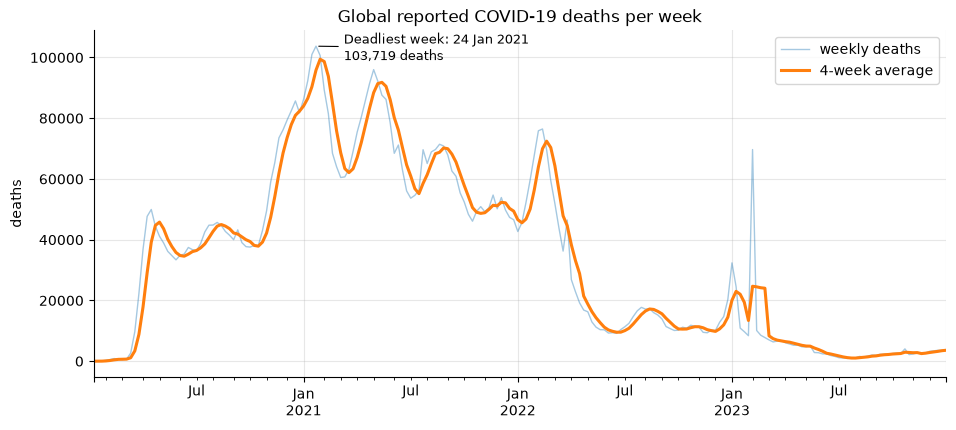

In [3]:
trend = q("q02_global_weekly_trend")
ax = trend.plot(x="week_end", y="global_deaths", lw=1, alpha=0.4, label="weekly deaths", legend=True)
trend.plot(x="week_end", y="deaths_4wk_avg", ax=ax, lw=2.2, label="4-week average")
ax.set(title="Global reported COVID-19 deaths per week", xlabel="", ylabel="deaths")
peak = q("q05_deadliest_global_weeks").iloc[0]
ax.annotate(f"Deadliest week: {peak.week_end:%d %b %Y}\n{peak.global_deaths:,.0f} deaths", (peak.week_end, peak.global_deaths),
            textcoords="offset points", xytext=(20, -10), fontsize=9, arrowprops={"arrowstyle": "-", "lw": 0.8})

## 3. Severity fell sharply
Case fatality rate per quarter, computed from flows (deaths ÷ cases in the quarter). The drop through 2022 reflects vaccination, prior infection, treatment and the milder Omicron variant. The 2023 bump is partly an artefact of testing collapse: fewer cases were recorded per death.

[Text(0.5, 1.0, 'Case fatality rate by quarter'),
 Text(0.5, 0, ''),
 Text(0, 0.5, 'CFR')]

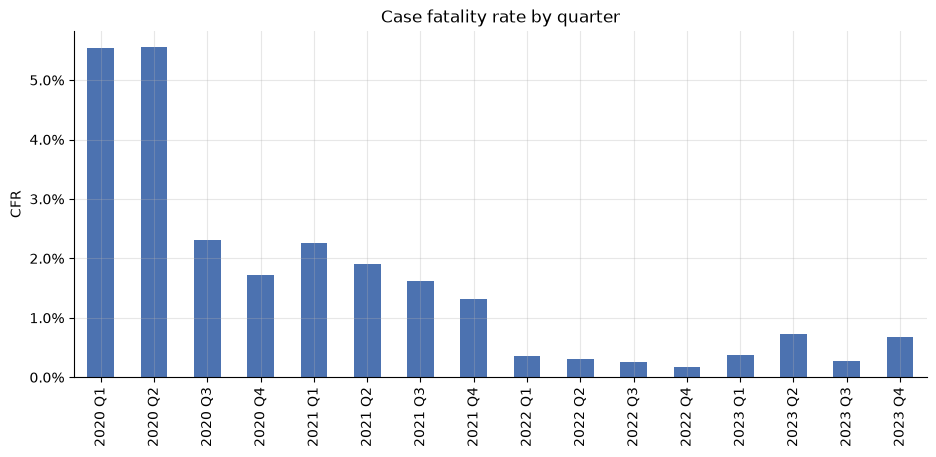

In [4]:
cfr = q("q12_cfr_by_quarter").assign(period=lambda d: d.year.astype(str) + " Q" + d.quarter.astype(str))
ax = cfr.plot.bar(x="period", y="cfr", legend=False, color="#4C72B0")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set(title="Case fatality rate by quarter", xlabel="", ylabel="CFR")

## 4. Where the burden fell
Population-weighted deaths per million over the full window. Reported deaths understate the burden in places with weak death registration (much of Africa and South Asia), so read low numbers as a floor.

,country_name,continent,cumulative_deaths_per_million,case_fatality_rate
0,Peru,South America,6587.397,0.049
1,Bulgaria,Europe,5659.358,0.029
2,North Macedonia,Europe,5415.066,0.028
3,Bosnia and Herzegovina,Europe,5111.080,0.041
4,Hungary,Europe,5058.802,0.022
5,Croatia,Europe,4782.916,0.014
6,Slovenia,Europe,4581.060,0.007
7,Georgia,Asia,4516.992,0.009
8,Czechia,Europe,4061.943,0.009
9,Moldova,Europe,4004.624,0.019


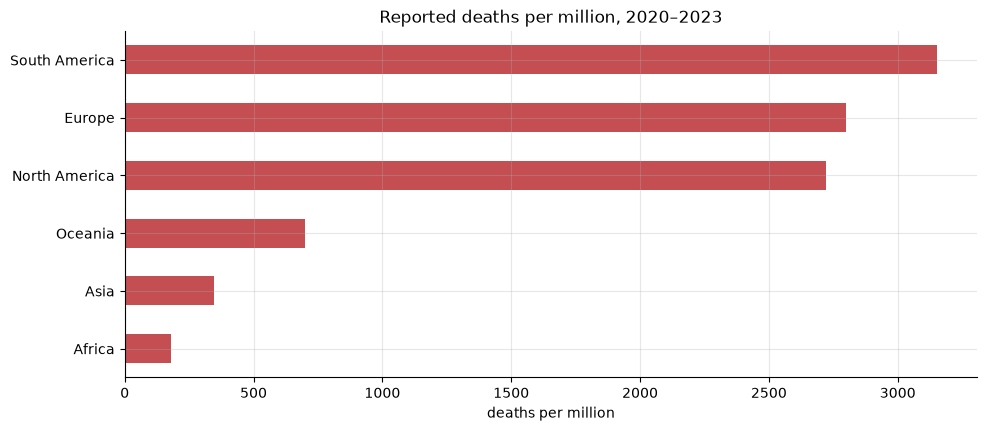

In [5]:
cont = q("q08_continent_burden").set_index("continent")
ax = cont["deaths_per_million"].sort_values().plot.barh(color="#C44E52")
ax.set(title="Reported deaths per million, 2020–2023", xlabel="deaths per million", ylabel="")
q("q06_top_countries_cumulative_deaths_per_million").round(3)

## 5. Vaccination and mortality: read with care
Countries grouped by vaccination coverage at the end of 2021 and compared on their 2022 outcomes. The most-vaccinated tercile shows **higher** reported deaths per million but a **much lower CFR**. This is confounding, not vaccine harm: highly vaccinated countries are older, richer and test far more, so they record more cases and more deaths. CFR (deaths per recorded case) is the fairer severity comparison.

,tercile,countries,min_vax_end_2021,max_vax_end_2021,deaths_per_million_2022,cfr_2022
0,1,52,0.0003,0.2249,13.2842,0.0102
1,2,52,0.2402,0.6102,113.4986,0.0057
2,3,52,0.6129,0.8845,272.7918,0.0024


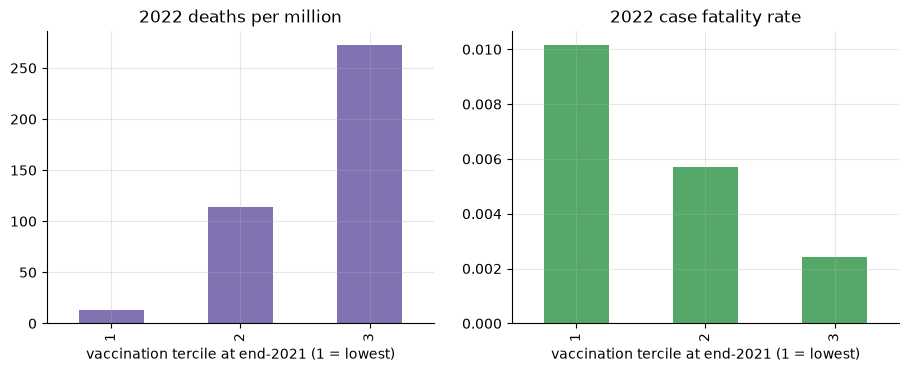

In [6]:
terc = q("q13_vaccination_tercile_vs_2022_mortality")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
terc.plot.bar(x="tercile", y="deaths_per_million_2022", ax=axes[0], legend=False, color="#8172B2", title="2022 deaths per million")
terc.plot.bar(x="tercile", y="cfr_2022", ax=axes[1], legend=False, color="#55A868", title="2022 case fatality rate")
for ax in axes: ax.set_xlabel("vaccination tercile at end-2021 (1 = lowest)")
terc.round(4)

## 6. Health-system strain
The peak share of each country's total hospital bed capacity occupied by COVID-19 patients, for countries that publish hospital occupancy (mostly Europe and the Americas).

In [7]:
q("q15_peak_covid_bed_occupancy").head(10).round(3)

/var/folders/p_/_49kds715ln05n7xh2vc_74w0000gn/T/ipykernel_75516/3913259006.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  q("q15_peak_covid_bed_occupancy").head(10).round(3)


,country_name,peak_week,covid_bed_occupancy_share,hosp_patients_per_million
0,Serbia,2020-12-27,0.247,1426.023
1,United Kingdom,2021-01-24,0.229,554.959
2,Malaysia,2021-08-15,0.210,412.338
3,Italy,2020-11-29,0.207,632.836
4,Spain,2021-01-31,0.187,545.298
5,Bulgaria,2021-04-11,0.185,1517.025
6,Portugal,2021-01-31,0.181,629.804
7,United States,2022-01-23,0.164,440.101
8,Lithuania,2021-01-03,0.154,880.748
9,Slovenia,2020-11-29,0.149,611.146


## 7. Data coverage caveat
By 2023 many countries had stopped reporting deaths regularly. OWID records that as zero; the pipeline turns these runs into **nulls** so they aren't read as 'COVID deaths reached zero'.

In [8]:
cov = q("q20_reporting_coverage")
print(f"{(cov.reporting_share < 1).sum()} of {len(cov)} countries (pop >= 1M) have reporting gaps")
cov.head(12)

42 of 161 countries (pop >= 1M) have reporting gaps


,country_name,weeks,weeks_with_death_reports,reporting_share,last_reported_week
0,Uzbekistan,208,113,0.543269,2022-03-06
1,Somalia,208,115,0.552885,2022-03-20
2,Kyrgyzstan,208,117,0.562500,2022-04-03
3,Laos,208,117,0.562500,2022-04-03
4,Cambodia,208,120,0.576923,2022-04-24
5,Belarus,208,130,0.625000,2022-07-03
6,Turkey,208,149,0.716346,2022-11-13
7,Netherlands,208,156,0.750000,2023-01-01
8,South Africa,208,159,0.764423,2023-01-22
9,Argentina,208,165,0.793269,2023-03-05
